# Week 9 Lab: Multimodal embeddings with CLIP (and a little audio)

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 2, 4

1. Embed **images and texts** in CLIP's shared space and compute similarities.
2. **Zero-shot classification** on CIFAR-10, and how the text prompt changes accuracy.
3. **Text-to-image retrieval** and precision@k.
4. Implement the **contrastive (InfoNCE) loss** that trains CLIP.
5. See the **modality gap** in the embedding space.
6. **Speech → text → image:** transcribe audio with Whisper, measure word error rate, then use the transcript to retrieve images.
7. (optional) Compare with **SigLIP**.

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **T4 GPU**. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. A GPU is optional: every cell has a CPU-friendly setting.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete. Questions marked ✍️ need a short written answer.

## Before running: follow the two encoder paths

A **modality** is a type of data. Here images and text are converted by
separate **encoders** into comparable vectors called **embeddings**.
Read each arrow as the data passed to the next block.

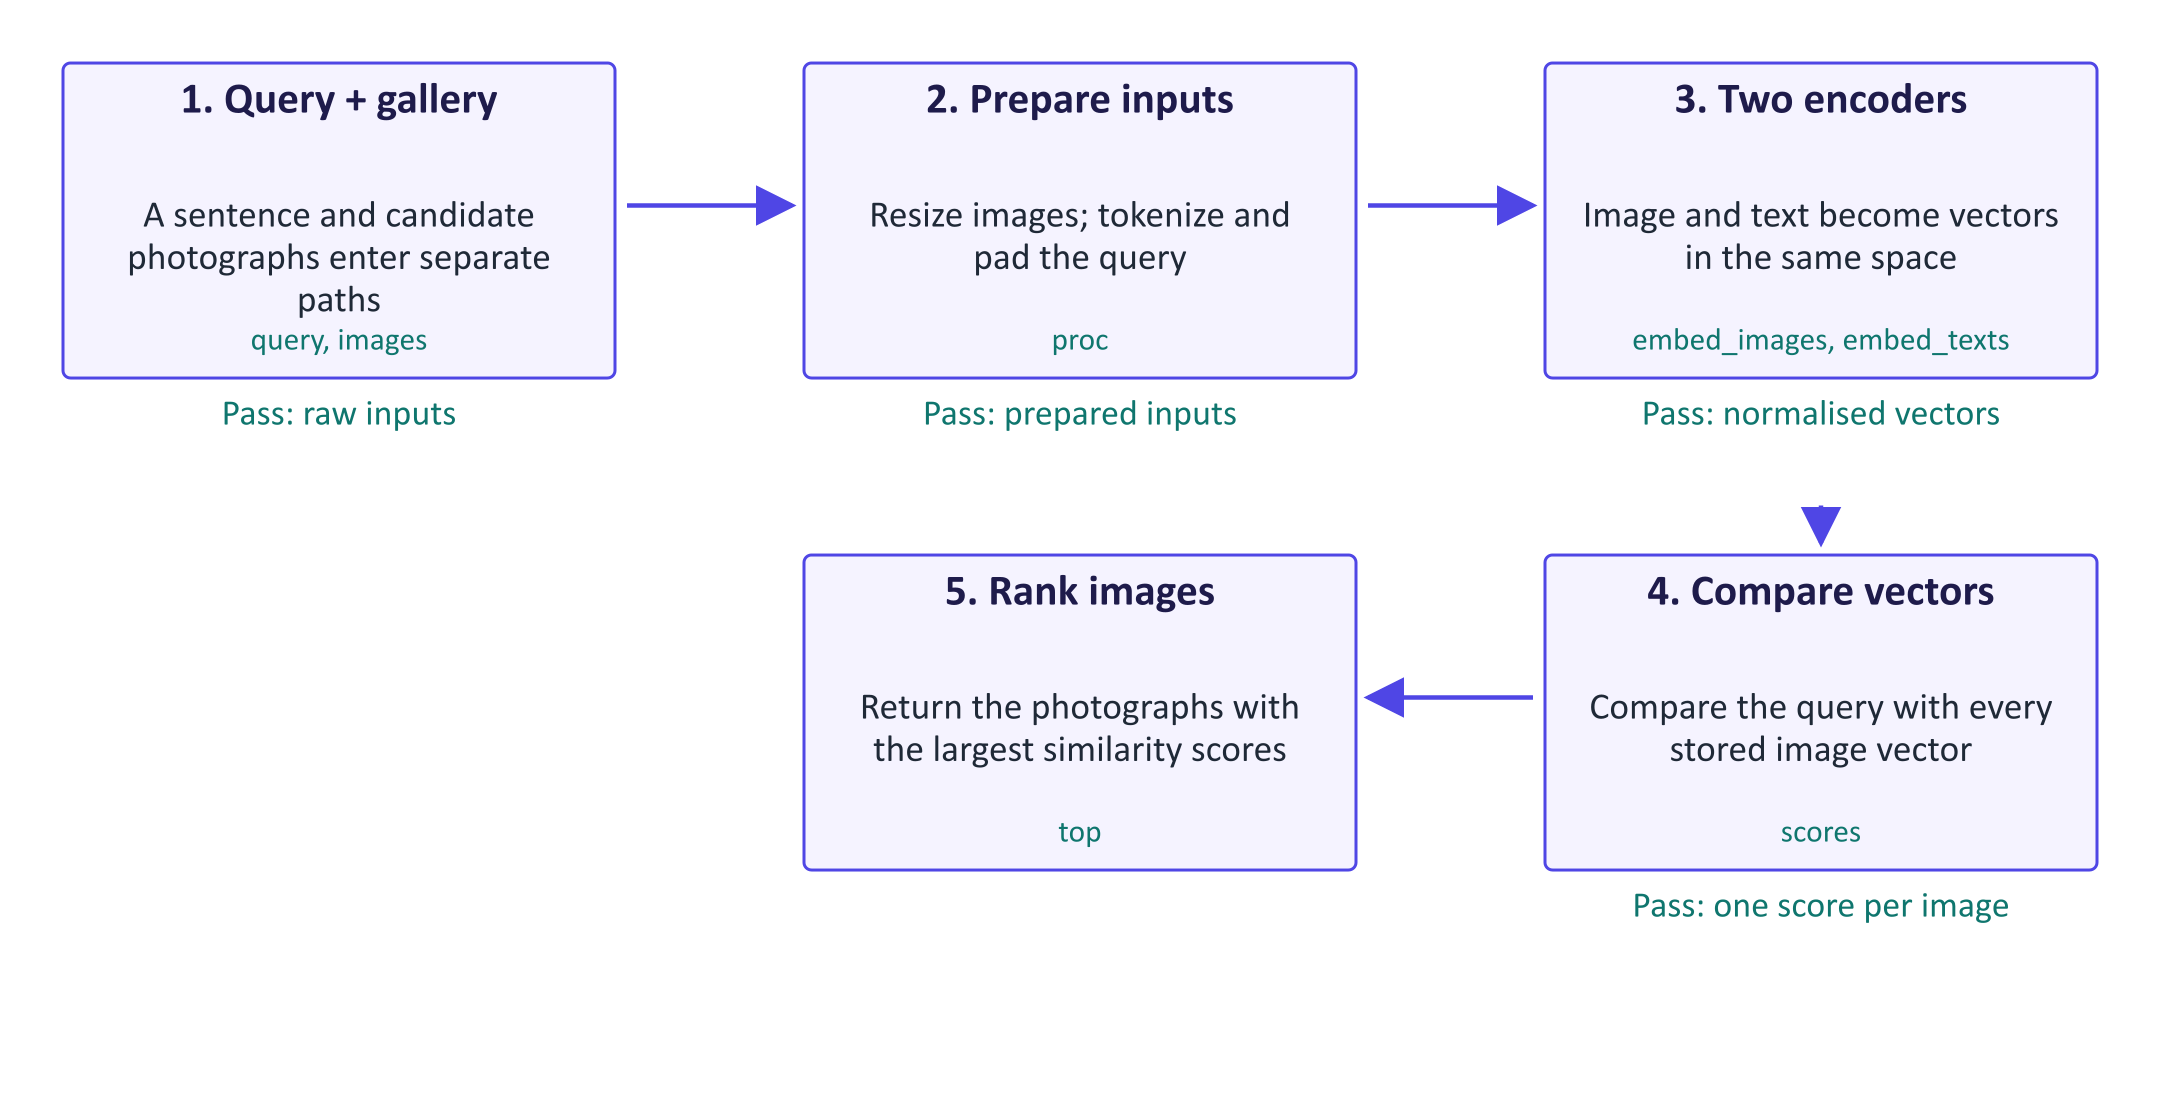

CLIP is already trained. This notebook evaluates its frozen representations;
computing `clip_loss` later does not update its weights.

## Lab route and code map

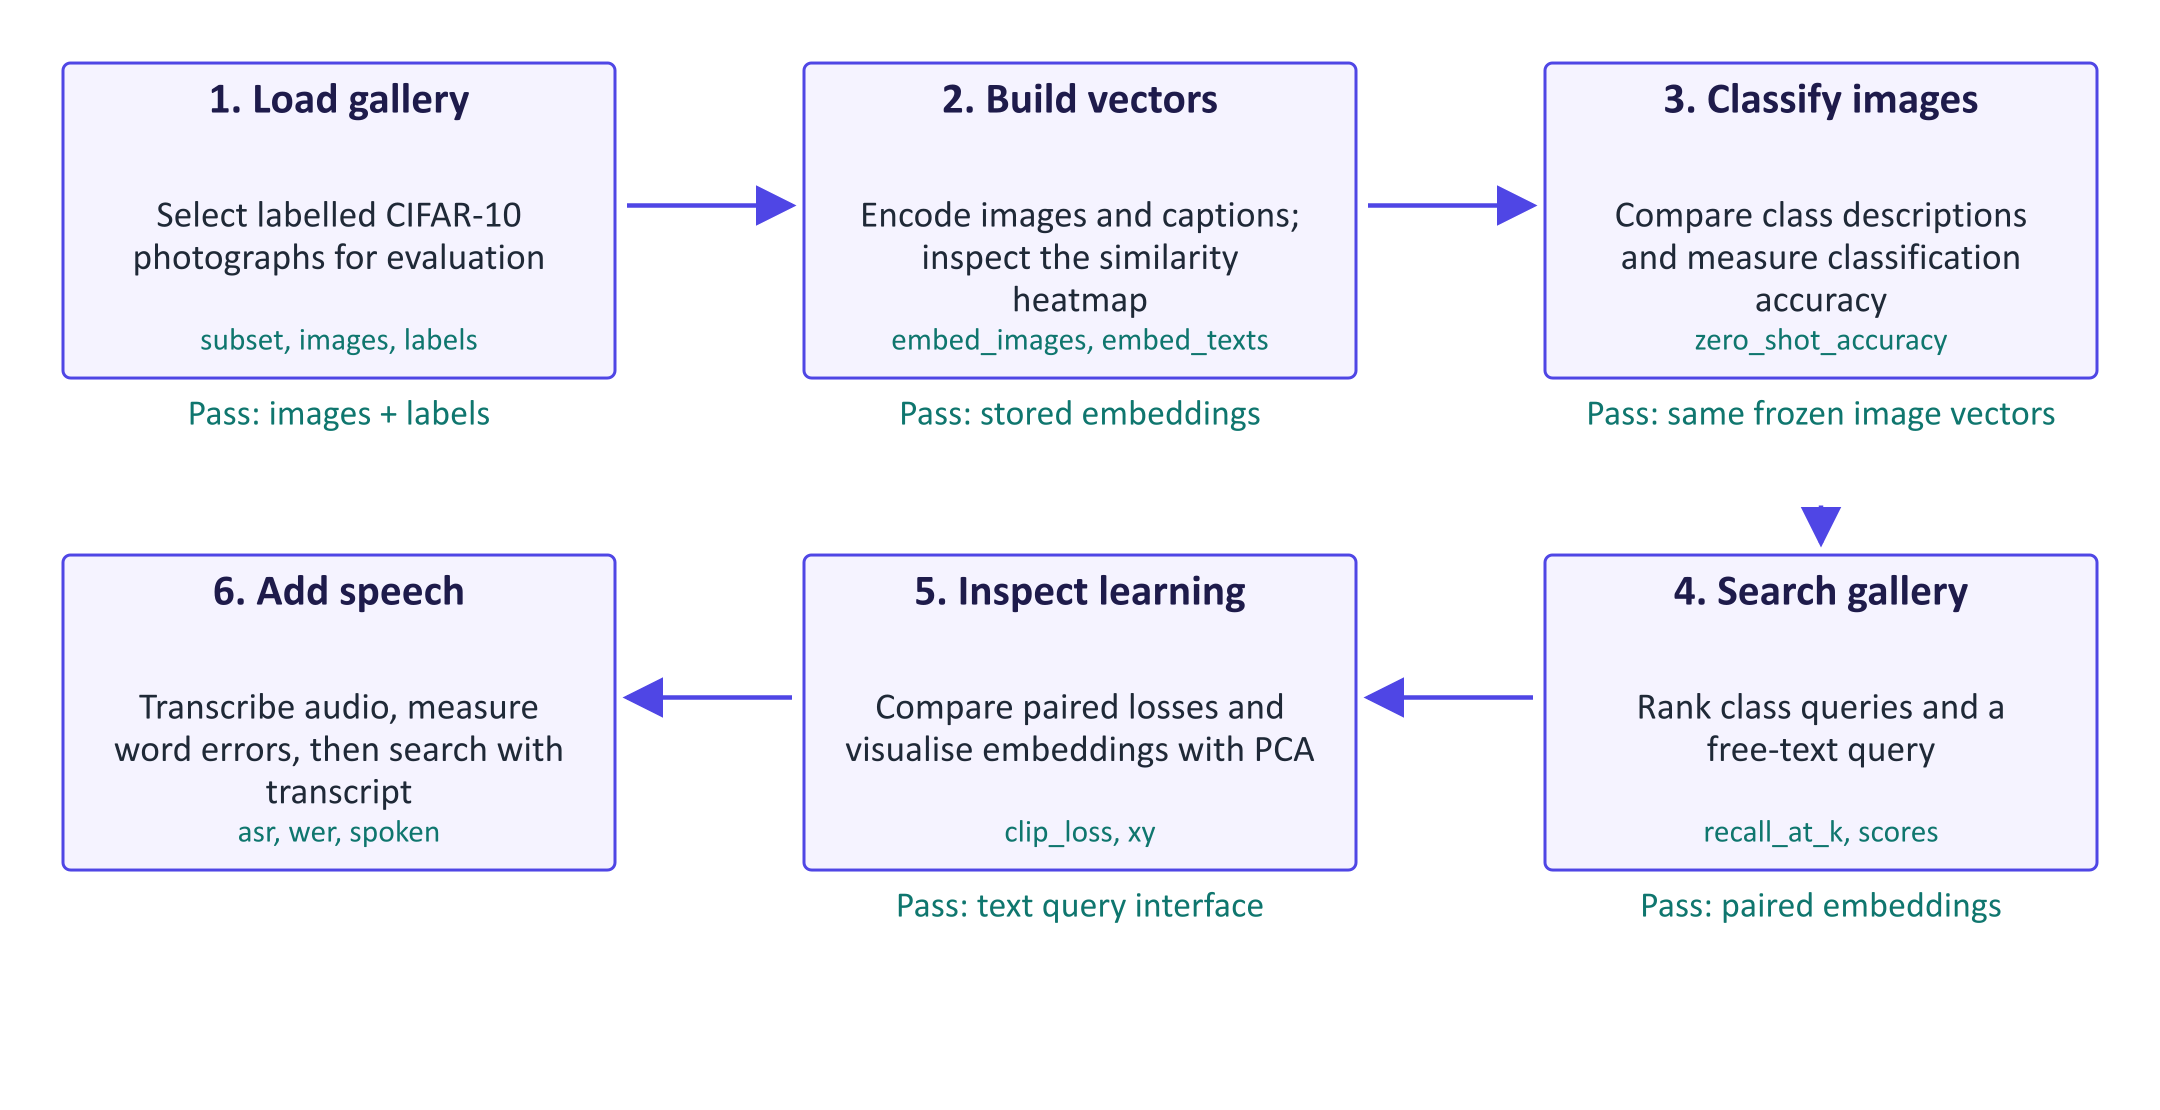

| Diagram block | Code to find | Inspect before continuing |
|---|---|---|
| Load gallery | `subset`, `images`, `labels` | One label belongs to each image. |
| Build vectors | `embed_images`, `embed_texts` | Rows, vector dimension and vector norms. |
| Classify images | `zero_shot_accuracy` | Accuracy changes across text templates. |
| Search gallery | `recall_at_k`, `scores` | Returned pictures and precision@k. |
| Inspect learning | `clip_loss`, `xy` | Correct/shuffled losses and the PCA projection. |
| Add speech | `asr`, `wer`, `spoken` | Reference words, transcript and retrieved classes. |

The historical function name `recall_at_k` is retained, but it computes
**precision@k**: relevant returned images divided by the number returned.
Recall instead divides by the total number of relevant items in the gallery.

In [ ]:
%pip install -q transformers datasets soundfile scikit-learn matplotlib pandas

In [ ]:
import io
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn.functional as F
from datasets import Audio, load_dataset
from transformers import CLIPModel, CLIPProcessor

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("device:", DEVICE, "| CLIP parameters:", f"{sum(p.numel() for p in clip.parameters()) / 1e6:.0f} M")

## Part 1 · One space for images and text

CLIP has an **image encoder** (a Vision Transformer) and a **text encoder** (a transformer). Each maps its input to a 512-dimensional vector in the **same space**, trained so that matching image–caption pairs are close.

**TODO 1:** complete `embed_images` and `embed_texts` so they return **L2-normalised** embeddings (use `F.normalize`).

In [ ]:
cifar = load_dataset("uoft-cs/cifar10", split="test")
CLASSES = cifar.features["label"].names
N = 100 if SMOKE else 1000
subset = cifar.shuffle(seed=0).select(range(N))
images = [im.convert("RGB") for im in subset["img"]]
labels = np.array(subset["label"])


@torch.no_grad()
def embed_images(imgs, batch=64):
    # Keep input order: row i must still represent image i after batching.
    out = []
    for i in range(0, len(imgs), batch):
        inputs = proc(images=imgs[i:i + batch], return_tensors="pt").to(DEVICE)
        feats = clip.vision_model(pixel_values=inputs["pixel_values"]).pooler_output
        feats = clip.visual_projection(feats)
        out.append(F.normalize(feats, dim=-1).cpu())
    return torch.cat(out)


@torch.no_grad()
def embed_texts(texts):
    # The attention mask distinguishes real text tokens from padding.
    inputs = proc(text=texts, return_tensors="pt", padding=True).to(DEVICE)
    feats = clip.text_projection(clip.text_model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"]).pooler_output)
    return F.normalize(feats, dim=-1).cpu()


img_emb = embed_images(images)
print("image embeddings:", tuple(img_emb.shape), "| norms:", img_emb.norm(dim=-1)[:3].numpy().round(3))

captions = ["a photo of a red car", "a small bird on a branch", "a cat sleeping", "a ship at sea", "a horse in a field", "an airplane in the sky"]
txt_emb = embed_texts(captions)
show_idx = [int(np.where(labels == CLASSES.index(c))[0][0]) for c in ["automobile", "bird", "cat", "ship", "horse", "airplane"]]
sim = img_emb[show_idx] @ txt_emb.T
# Rows are chosen images, columns are captions; a cell is one comparison.
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.3, 1]})
ax[0].imshow(np.hstack([np.array(images[i].resize((64, 64))) for i in show_idx])); ax[0].axis("off"); ax[0].set_title("images")
im = ax[1].imshow(sim.numpy(), cmap="Purples"); ax[1].set_xticks(range(6)); ax[1].set_xticklabels([c[:14] for c in captions], rotation=45, ha="right")
ax[1].set_ylabel("image"); ax[1].set_title("cosine similarity"); plt.colorbar(im); plt.tight_layout(); plt.show()

## Part 2 · Zero-shot classification

No training: embed one text per class and assign each image to the most similar text.

**TODO 2:** complete `zero_shot_accuracy(templates)`: for each class build the prompts from **all** templates, embed them, **average** the embeddings per class (then re-normalise), predict with the highest cosine similarity, and return accuracy.

In [ ]:
def zero_shot_accuracy(templates):
    class_emb = []
    for c in CLASSES:
        e = embed_texts([t.format(c) for t in templates]).mean(dim=0)
        class_emb.append(F.normalize(e, dim=-1))
    class_emb = torch.stack(class_emb)
    pred = (img_emb @ class_emb.T).argmax(dim=1).numpy()
    return float((pred == labels).mean()), pred


results = {}
for name, templates in {
    "label only: '{}'": ["{}"],
    "'a photo of a {}.'": ["a photo of a {}."],
    "ensemble of 5 templates": ["a photo of a {}.", "a blurry photo of a {}.", "a low resolution photo of a {}.",
                                "a close-up photo of a {}.", "a pixelated photo of a {}."],
}.items():
    acc, pred = zero_shot_accuracy(templates)
    results[name] = acc
    print(f"{name:28s} accuracy = {acc:.3f}")
last_pred = pred

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, last_pred, labels=range(10))
plt.figure(figsize=(6.5, 5.5)); plt.imshow(cm, cmap="Purples")
plt.xticks(range(10), CLASSES, rotation=60); plt.yticks(range(10), CLASSES); plt.xlabel("predicted"); plt.ylabel("true")
plt.title("Zero-shot CLIP on CIFAR-10"); plt.colorbar(); plt.show()

✍️ **Question 1.** CLIP was never trained on CIFAR-10 labels. Why does zero-shot classification work, and why does the text template matter? Which classes are confused, and why might that be?

**✅ Model answer:**
CLIP learned from about 400 million image–caption pairs to place images near the captions that describe them. A class name turned into a caption ("a photo of a cat") lands near images of cats, so choosing the most similar class text is a classifier with no task-specific training. The template matters because CLIP's text encoder was trained on natural captions, not isolated words: "a photo of a {}" resembles its training text, and averaging several templates (prompt ensembling) reduces the variance from any single phrasing. Typical confusions are cat/dog, deer/horse and automobile/truck: visually similar classes at CIFAR's tiny 32×32 resolution (upscaled to 224×224), which is also far from CLIP's usual training images.

## Part 3 · Text-to-image retrieval and precision@k

Retrieval is the same maths in the other direction: embed a query text and rank all images.

**TODO 3:** complete `recall_at_k(k)`: for each class query "a photo of a {class}.", rank all images by similarity and count the fraction of the top-k images whose label is that class. The historical name is retained, but this is **precision@k averaged over classes**, not recall@k.

In [ ]:
def recall_at_k(k=10):
    # scores has one row per class query and one column per gallery image.
    q = embed_texts([f"a photo of a {c}." for c in CLASSES])
    scores = q @ img_emb.T
    topk = scores.topk(k, dim=1).indices.numpy()
    return float(np.mean([(labels[topk[c]] == c).mean() for c in range(len(CLASSES))]))


for k in (1, 5, 10):
    print(f"precision@{k} = {recall_at_k(k):.3f}")

query = "a red sports car on a road"
scores = (embed_texts([query]) @ img_emb.T)[0]
top = scores.topk(6).indices
plt.figure(figsize=(9, 1.8)); plt.imshow(np.hstack([np.array(images[i].resize((96, 96))) for i in top])); plt.axis("off")
plt.title(f"top-6 images for: '{query}'"); plt.show()

## Part 4 · The contrastive loss that trains CLIP

For a batch of $N$ matching pairs with normalised embeddings $u_i$ (images) and $v_i$ (texts), the logits are $s_{ij} = u_i \cdot v_j / \tau$. CLIP minimises the **symmetric cross-entropy** where the correct "class" of image $i$ is text $i$ and vice versa:

$$\mathcal{L} = \frac{1}{2}\left(\mathrm{CE}(S, \mathrm{diag}) + \mathrm{CE}(S^\top, \mathrm{diag})\right)$$

**TODO 4:** implement `clip_loss(u, v, tau)`.

Read the similarity matrix in both directions: a row asks which caption
matches an image; a column asks which image matches a caption. The original
ordering of each paired list defines the targets. These calls only measure
the loss of pretrained embeddings; there is no optimiser or backward pass.

In [ ]:
def clip_loss(u, v, tau=0.07):
    logits = (u @ v.T) / tau
    target = torch.arange(len(u))
    return 0.5 * (F.cross_entropy(logits, target) + F.cross_entropy(logits.T, target))


batch_imgs = [images[i] for i in show_idx]
u, v = embed_images(batch_imgs), embed_texts(captions)
print(f"loss, correct pairs:  {clip_loss(u, v):.3f}")
print(f"loss, shuffled pairs: {clip_loss(u, v[torch.randperm(len(v))]):.3f}")
print(f"loss of random guessing = ln(N) = {np.log(len(u)):.3f}")

✍️ **Question 2.** Explain why the loss is low for correct pairs and high for shuffled pairs. What role do the other captions in the batch play, and why did CLIP train with very large batches (32,768)?

**✅ Model answer:**
Each image must pick out its own caption among all captions in the batch (a classification over N options), and vice versa. With correct pairs the diagonal similarities are the largest, so the cross-entropy is low; after shuffling, the "correct" targets are no longer the most similar texts, so the loss rises well above ln(N). The other captions act as negatives: the model learns by pulling matching pairs together and pushing non-matching pairs apart. Larger batches give more (and harder) negatives per step, which makes the task more informative and the embeddings more discriminative; CLIP used 32,768 pairs per batch. SigLIP replaces the softmax with independent sigmoid (binary) losses per pair, which works well with smaller batches.

## Part 5 · The modality gap
Project image and text embeddings together to 2-D with PCA.
PCA is a compressed view: nearby plotted points need not preserve every
distance or relationship in the original 512-dimensional space.

In [ ]:
from sklearn.decomposition import PCA

class_txt = embed_texts([f"a photo of a {c}." for c in CLASSES])
M = min(300, len(img_emb))
all_emb = torch.cat([img_emb[:M], class_txt]).numpy()
xy = PCA(n_components=2, random_state=0).fit_transform(all_emb)
plt.figure(figsize=(8.5, 5.5))
plt.scatter(xy[:M, 0], xy[:M, 1], c=labels[:M], cmap="tab10", s=10, alpha=0.7, label="images")
plt.scatter(xy[M:, 0], xy[M:, 1], c=range(10), cmap="tab10", s=180, marker="*", edgecolor="black", label="class texts")
kinds = plt.legend(loc="upper center")
plt.gca().add_artist(kinds)  # keep this legend when adding the colour key (the text stars sit too close together to label)
colours = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab10(i), label=c) for i, c in enumerate(CLASSES)]
plt.legend(handles=colours, title="class", loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.title("Images and texts occupy different regions (the 'modality gap')"); plt.tight_layout(); plt.show()
print("mean cosine similarity, image–image:", float((img_emb[:200] @ img_emb[:200].T).mean()), "| image–text:", float((img_emb[:200] @ class_txt.T).mean()))

## Part 6 · Speech → text → image

**Whisper** is an encoder–decoder transformer that turns audio (as a log-mel spectrogram) into text.

**TODO 5:** implement word error rate (WER) = (substitutions + deletions + insertions) / number of reference words, using edit distance on words.

The edit-distance table compares prefixes of the reference and transcript.
Its row and column lengths therefore include an empty prefix. Inspect the
actual words as well as the final rate; a transcript error can change search.

In [ ]:
from transformers import pipeline

asr = pipeline("automatic-speech-recognition", model="openai/whisper-tiny" if SMOKE else "openai/whisper-base", device=0 if DEVICE == "cuda" else -1)
speech = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation").cast_column("audio", Audio(decode=False))


def load_audio(ex):
    arr, sr = sf.read(io.BytesIO(ex["audio"]["bytes"]))
    return {"raw": arr.astype(np.float32), "sampling_rate": sr}


def wer(reference, hypothesis):
    r, h = reference.lower().split(), hypothesis.lower().replace(",", "").replace(".", "").split()
    d = np.zeros((len(r) + 1, len(h) + 1), dtype=int)
    d[:, 0] = range(len(r) + 1)
    d[0, :] = range(len(h) + 1)
    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            d[i, j] = min(d[i - 1, j] + 1, d[i, j - 1] + 1, d[i - 1, j - 1] + (r[i - 1] != h[j - 1]))
    return d[len(r), len(h)] / max(1, len(r))


rows = []
for ex in speech.select(range(3 if SMOKE else 10)):
    hyp = asr(load_audio(ex))["text"].strip()
    rows.append({"reference": ex["text"].lower()[:70], "whisper": hyp[:70], "WER": round(wer(ex["text"], hyp), 3)})
df_asr = pd.DataFrame(rows)
print("mean WER:", df_asr.WER.mean().round(3))
df_asr

In [ ]:
arr = load_audio(speech[0])["raw"]
plt.figure(figsize=(10, 2.5)); plt.specgram(arr, Fs=16000, NFFT=400, noverlap=240, cmap="magma")
plt.xlabel("time (s)"); plt.ylabel("frequency (Hz)"); plt.title("Illustrative audio spectrogram: linear frequency bins"); plt.show()

Now chain the modalities: speech is transcribed by Whisper and the transcript retrieves images through CLIP. The LibriSpeech clips are audiobook sentences rather than image descriptions, so compare the retrieved classes for the transcript with those for a typed descriptive query. (Record your own spoken query with a phone and load it with `soundfile` for a better test.)

In [ ]:
spoken = asr(load_audio(speech[1]))["text"]
print("transcript:", spoken)
for text_query in [spoken, "a photo of a ship on the water"]:
    top = (embed_texts([text_query]) @ img_emb.T)[0].topk(5).indices
    print(f"query: {text_query[:60]!r} -> classes of top-5 images: {[CLASSES[labels[i]] for i in top]}")

✍️ **Question 3.** What are the weak points of a speech → text → image pipeline compared with a model that embeds audio directly? Give one advantage of the pipeline.

**✅ Model answer:**
Errors compound: every transcription error (WER) propagates into retrieval, and information in the audio that is not words (tone, emotion, background sounds, speaker identity) is lost when converting to text. Each stage adds latency and cost. A model with a shared audio–image–text space (or an end-to-end multimodal model) can use that non-verbal information and avoid cascaded errors. Advantages of the pipeline: each component is replaceable and testable on its own (we can measure WER and retrieval separately), the intermediate transcript is human-readable and auditable, and strong off-the-shelf models exist for each step.

## Optional · SigLIP

SigLIP replaces CLIP's softmax contrastive loss with a **sigmoid** loss on every image–text pair. Try zero-shot classification with `google/siglip-base-patch16-224` (use `AutoModel` and `AutoProcessor`, `padding="max_length"`) and compare accuracy.

| Experiment | Setting | Result |
|---|---|---|
| Zero-shot CIFAR-10 | label only / template / ensemble | |
| Retrieval | precision@1, @5, @10 | |
| Contrastive loss | correct vs shuffled | |
| Whisper | mean WER | |

In [ ]:
# Instructor tooling: save measured results for the lecture slides (only when requested).
if os.environ.get("GENAI_RESULTS_PATH"):
    import json
    payload = {"n_images": int(len(img_emb)), "zero_shot": results,
               "precision_at_k": {k: recall_at_k(k) for k in (1, 5, 10)},
               "loss_correct": float(clip_loss(u, v)), "loss_shuffled": float(clip_loss(u, v[torch.randperm(len(v), generator=torch.Generator().manual_seed(0))])),
               "loss_random": float(np.log(len(u))), "mean_wer": float(df_asr.WER.mean()),
               "asr_examples": df_asr.head(3).to_dict("records"),
               "confusion": cm.tolist(), "classes": CLASSES}
    with open(os.environ["GENAI_RESULTS_PATH"], "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, default=float)
    print("results saved")